In [12]:
# 0. importing related libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

In [4]:
# 1. loading data

df = pd.read_csv("Dataset_campus_wifi_Cleaned.csv")
df

,Record_ID,Timestamp_Hour,Day_of_Week,Location,Num_Connected_Devices,Bandwidth_Usage_Mbps,AP_Load_Percent,Network_Latency_ms,Packet_Loss_Rate_Percent,Signal_Strength_dBm,Retransmission_Rate_Percent,Throughput_Mbps,Active_Sessions,Channel_Utilization_Percent,Congestion_Level
0,5077,15,Friday,Cafeteria,136.904535,159.14,36.80,39.70,1.72,-55.6,2.82,137.271756,210.0,28.86,Low
1,4532,9,Monday,Library,58.567281,64.59,26.38,34.90,1.22,-47.2,2.06,52.816405,80.0,22.63,Low
2,1498,20,Wednesday,Lecture_Hall_1,5.000000,5.00,2.73,14.90,0.15,-40.7,0.29,4.606722,30.0,5.91,Low
3,5454,21,Tuesday,Hostel_B,59.546069,43.90,19.00,31.24,1.04,-43.2,NaN,39.062429,88.0,14.41,Low
4,5512,7,Thursday,Lab_Block_B,50.213885,46.81,13.75,31.10,0.62,-48.3,1.70,43.310416,40.0,7.15,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5504,2769,6,Thursday,Admin_Block,20.700667,5.00,6.24,22.80,0.53,-42.9,0.83,4.887468,30.0,9.34,Low
5505,2738,19,Tuesday,Admin_Block,41.242511,50.04,8.45,18.40,1.66,-44.6,2.61,39.449502,45.0,11.62,Low
5506,4241,22,Friday,Lecture_Hall_1,6.874638,5.00,2.14,20.60,0.26,-42.6,0.56,4.883838,5.0,0.00,Low
5507,6306,12,Tuesday,Lecture_Hall_2,161.778438,173.69,65.59,63.50,2.71,-57.5,4.10,148.431633,220.0,64.33,Low


In [5]:
# 4.  Encoding & Normalization (Preprocessing Part 2)

# --- Encode Target Column ---
le = LabelEncoder()
df['Congestion_Encoded'] = le.fit_transform(df['Congestion_Level'])

print("=== Target Encoding ===")
print("Classes mapped:", dict(zip(le.classes_, le.transform(le.classes_))))
print(df[['Congestion_Level', 'Congestion_Encoded']].value_counts().reset_index().sort_values('Congestion_Encoded'))

# --- Encode Categorical Features ---
print("\n=== Before One-Hot Encoding ===")
print("Columns:", list(df.columns))
print("Shape:", df.shape)

df = pd.get_dummies(df, columns=['Day_of_Week', 'Location'], drop_first=True)

print("\n=== After One-Hot Encoding ===")
print("New columns added:", [c for c in df.columns if 'Day_of_Week' in c or 'Location' in c])
print("Shape after encoding:", df.shape)

# --- Feature Matrix ---
X = df.drop(['Record_ID', 'Congestion_Level', 'Congestion_Encoded'], axis=1)
y = df['Congestion_Encoded']

print("\n=== Feature Matrix ===")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features used:\n", list(X.columns))

# --- Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n=== After Standard Scaling ===")
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Mean of each feature (should be ~0):")
print(X_scaled_df.mean().round(4))
print("\nStd of each feature (should be ~1):")
print(X_scaled_df.std().round(4))
print("\nSample of scaled data (first 5 rows):")
print(X_scaled_df.head())

=== Target Encoding ===
Classes mapped: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
  Congestion_Level  Congestion_Encoded  count
2             High                   0    104
0              Low                   1   5088
1           Medium                   2    317

=== Before One-Hot Encoding ===
Columns: ['Record_ID', 'Timestamp_Hour', 'Day_of_Week', 'Location', 'Num_Connected_Devices', 'Bandwidth_Usage_Mbps', 'AP_Load_Percent', 'Network_Latency_ms', 'Packet_Loss_Rate_Percent', 'Signal_Strength_dBm', 'Retransmission_Rate_Percent', 'Throughput_Mbps', 'Active_Sessions', 'Channel_Utilization_Percent', 'Congestion_Level', 'Congestion_Encoded']
Shape: (5509, 16)

=== After One-Hot Encoding ===
New columns added: ['Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Sunday', 'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday', 'Location_Cafeteria', 'Location_Hostel_A', 'Location_Hostel_B', 'Location_Lab_Block_A', 'Location_Lab_Block_B', 'Loca

In [7]:
# this was the second part of Data preprocessing and we encoded (with one hot encoding) and normalized (with standard scaling) and stored the dataset in new CSV file.
# refer to next jupitor notebook : 04_dimensinality_reduction.ipynb .

df.to_csv("Dataset_campus_wifi_Encoded_and_Normalised.csv", index=False)

In [10]:

imputer = SimpleImputer(strategy='median')
X_scaled = imputer.fit_transform(X_scaled)

PCA reduced to 16 components


Text(0, 0.5, 'Cumulative Explained Variance')

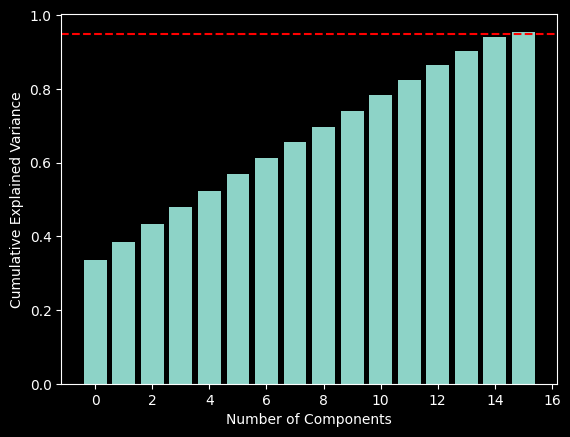

In [11]:
# 5A. Dimentionality Reduction by Feature Selection by PCA

pca = PCA(n_components=0.95)  # retain 95% variance
X_pca = pca.fit_transform(X_scaled)
print(f"PCA reduced to {X_pca.shape[1]} components")

# Plot explained variance
plt.bar(range(len(pca.explained_variance_ratio_)),
        np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.95, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [13]:
# 5B. Forward Selection

lr = LogisticRegression(max_iter=1000)
sfs_forward = SequentialFeatureSelector(lr, k_features='best',
              forward=True, scoring='accuracy', cv=5)
sfs_forward.fit(X_scaled, y)
X_forward = sfs_forward.transform(X_scaled)
print("Selected features:", sfs_forward.k_feature_names_)

Selected features: ('0', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '17', '18', '20', '21', '22', '23', '25')


In [14]:
# 5C. Backward Elimination

sfs_backward = SequentialFeatureSelector(lr, k_features='best',
               forward=False, scoring='accuracy', cv=5)
sfs_backward.fit(X_scaled, y)
X_backward = sfs_backward.transform(X_scaled)

In [16]:
#This was the feature selection section, and all the procedures are being done here. Now the modified data frame is being stored to a CSV file named FeatureSelectedData.csv 
#Refer to the next Jupyter notebook : Model_evaluation.ipynb  

X_pca_df = pd.DataFrame(X_pca)
X_pca_df['Congestion_Encoded'] = y.values
X_pca_df.to_csv('Dataset_campus_wifi_Feature_Selected.csv', index=False)